In [23]:
import torchvision.datasets as datasets
import torchvision.transforms as transforms

# Define transformations to apply to the images
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Example normalization
])

# Load the SVHN training dataset
train_dataset = datasets.SVHN(root='./data', split='train', transform=transform, download=True)

# Load the SVHN test dataset
test_dataset = datasets.SVHN(root='./data', split='test', transform=transform, download=True)

In [24]:
train_dataset.data.mean(axis=(0, 2, 3)), train_dataset.data.std(axis=(0, 2, 3))  # Check mean and std of training data

(array([111.60893668, 113.16127466, 120.56512767]),
 array([50.49768174, 51.2589843 , 50.24421614]))

In [25]:
import torch
from torch.utils.data import DataLoader

import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import matplotlib.pyplot as plt

def train_resnet18(optimizer_class, use_curvy=False, batch_size=128, plot=True, **optimizer_kwargs):
	# Set device
	device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
	
	# Create data loaders
	train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
	test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

	# Initialize ResNet-18 model
	model = models.resnet18(pretrained=False, num_classes=10)  # SVHN has 10 classes
	model = model.to(device)
	
	# Initialize optimizer
	if use_curvy:
		optimizer = optimizer_class(model.parameters(), model=model, **optimizer_kwargs)
	else:
		optimizer = optimizer_class(model.parameters(), **optimizer_kwargs)

	# Loss function
	criterion = nn.CrossEntropyLoss()
	
	# Training parameters
	num_epochs = 20
	train_losses = []
	test_losses = []
	
	for epoch in range(num_epochs):
		# Training phase
		model.train()
		train_loss = 0.0
		for batch_idx, (data, target) in enumerate(train_loader):
			data, target = data.to(device), target.to(device)
			
			optimizer.zero_grad()
			output = model(data)
			loss = criterion(output, target)
			loss.backward()
			optimizer.step()
			
			train_loss += loss.item()
		
		train_loss /= len(train_loader)
		train_losses.append(train_loss)
		
		# Testing phase
		model.eval()
		test_loss = 0.0
		total = 0
		total_correct = 0
		with torch.no_grad():
			for data, target in test_loader:
				data, target = data.to(device), target.to(device)
				output = model(data)
				loss = criterion(output, target)
				test_loss += loss.item()
				_, predicted = output.max(1)
				total += target.size(0)
				total_correct += predicted.eq(target).sum().item()
		
		test_loss /= len(test_loader)
		test_losses.append(test_loss)

		print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}, Test Accuracy: {total_correct/total:.4f}')
	
	if plot:
		# Plot loss curves
		plt.figure(figsize=(10, 6))
		plt.plot(range(1, num_epochs+1), train_losses, label='Training Loss')
		plt.plot(range(1, num_epochs+1), test_losses, label='Testing Loss')
		plt.xlabel('Epoch')
		plt.ylabel('Loss')
		plt.title('Training and Testing Loss Curves')
		plt.legend()
		plt.grid(True)
		plt.show()
	
	return model, train_losses, test_losses

/home/aarsh.wankar/miniconda/envs/ml/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/aarsh.wankar/miniconda/envs/ml/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Epoch 1/20, Train Loss: 0.6851, Test Loss: 0.4488, Test Accuracy: 0.8570
Epoch 2/20, Train Loss: 0.3638, Test Loss: 0.3834, Test Accuracy: 0.8842
Epoch 3/20, Train Loss: 0.2913, Test Loss: 0.3293, Test Accuracy: 0.9007
Epoch 4/20, Train Loss: 0.2509, Test Loss: 0.3103, Test Accuracy: 0.9063
Epoch 5/20, Train Loss: 0.2187, Test Loss: 0.3052, Test Accuracy: 0.9087
Epoch 6/20, Train Loss: 0.1900, Test Loss: 0.2756, Test Accuracy: 0.9193
Epoch 7/20, Train Loss: 0.1670, Test Loss: 0.3030, Test Accuracy: 0.9142
Epoch 8/20, Train Loss: 0.1430, Test Loss: 0.2744, Test Accuracy: 0.9235
Epoch 9/20, Train Loss: 0.1239, Test Loss: 0.2763, Test Accuracy: 0.9258
Epoch 10/20, Train Loss: 0.1077, Test Loss: 0.2867, Test Accuracy: 0.9244
Epoch 11/20, Train Loss: 0.0924, Test Loss: 0.2834, Test Accuracy: 0.9276
Epoch 12/20, Train Loss: 0.0793, Test Loss: 0.2917, Test Accuracy: 0.9254
Epoch 13/20, Train Loss: 0.0663, Test Loss: 0.3184, Test Accuracy: 0.9256
Epoch 14/20, Train Loss: 0.0626, Test Loss: 0.3

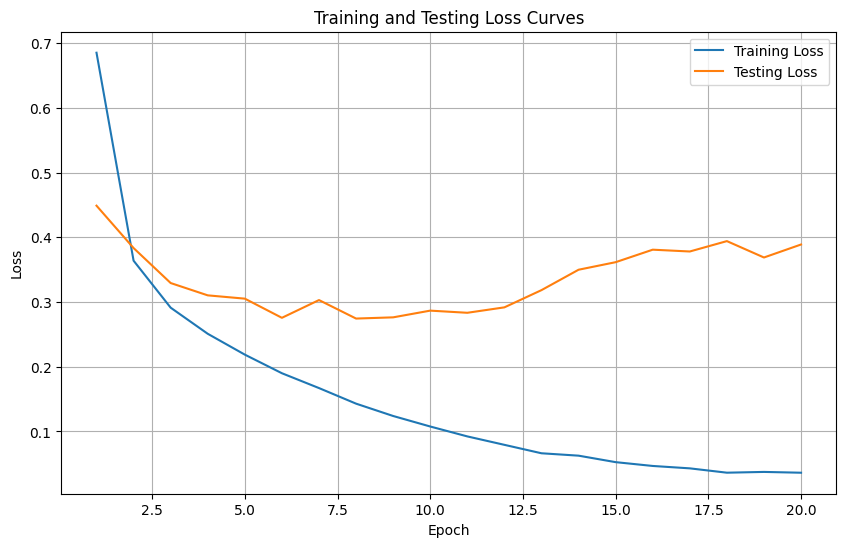

In [26]:
# Train ResNet-18 with Adam optimizer
model, train_losses, test_losses = train_resnet18(optim.Adam, lr=0.001)

/home/aarsh.wankar/Hessian/DeepHessian/Curvy/curvy.py:97: UserWarning: Hessian computation failed: 'int' object is not callable
  warnings.warn(f"Hessian computation failed: {str(e)}")


Epoch 1/20, Train Loss: 1.0580, Test Loss: 0.6112, Test Accuracy: 0.8075
Epoch 2/20, Train Loss: 0.4682, Test Loss: 0.4566, Test Accuracy: 0.8587
Epoch 3/20, Train Loss: 0.3510, Test Loss: 0.4081, Test Accuracy: 0.8724
Epoch 4/20, Train Loss: 0.2800, Test Loss: 0.4110, Test Accuracy: 0.8718
Epoch 5/20, Train Loss: 0.2238, Test Loss: 0.3945, Test Accuracy: 0.8813
Epoch 6/20, Train Loss: 0.1769, Test Loss: 0.4020, Test Accuracy: 0.8812
Epoch 7/20, Train Loss: 0.1365, Test Loss: 0.4359, Test Accuracy: 0.8785
Epoch 8/20, Train Loss: 0.1091, Test Loss: 0.4478, Test Accuracy: 0.8808
Epoch 9/20, Train Loss: 0.0863, Test Loss: 0.4575, Test Accuracy: 0.8806
Epoch 10/20, Train Loss: 0.0670, Test Loss: 0.4560, Test Accuracy: 0.8859
Epoch 11/20, Train Loss: 0.0555, Test Loss: 0.4673, Test Accuracy: 0.8879
Epoch 12/20, Train Loss: 0.0433, Test Loss: 0.4846, Test Accuracy: 0.8897
Epoch 13/20, Train Loss: 0.0338, Test Loss: 0.5036, Test Accuracy: 0.8891
Epoch 14/20, Train Loss: 0.0289, Test Loss: 0.5

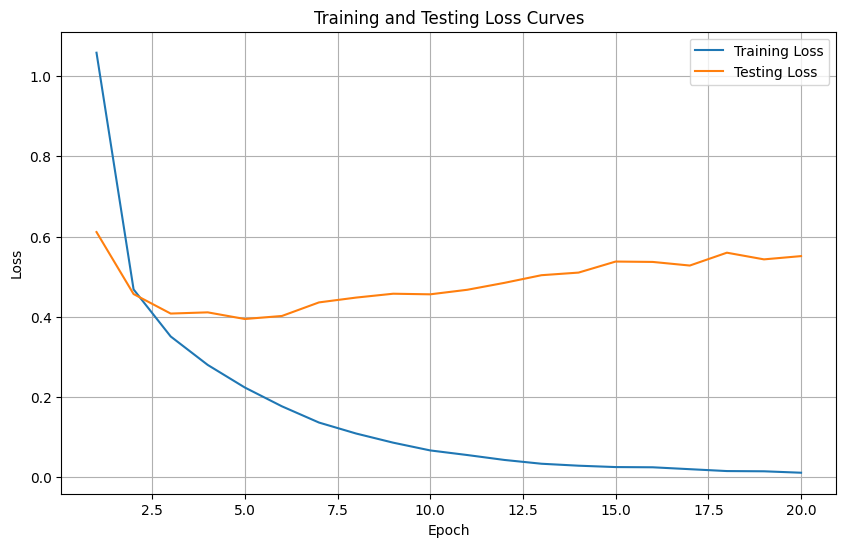

In [27]:
from PyHessian.pyhessian.hessian import hessian
from curvy import Curvy

# optimizer_curvy = Curvy(model_curvy.parameters())

curvy_model, curvy_train, curvy_test = train_resnet18(Curvy, use_curvy=True, batch_size=64, lr=1e-3, hessian_epsilon=1e-3, 
                        momentum=0.9, hessian_compute_interval=50, 
                        hessian_n_iter=100, criterion=nn.CrossEntropyLoss(), hessian_computer=hessian, 
                        train_x=train_dataset.data, train_y=train_dataset.labels, cuda=True)

In [ ]:
from PyHessian.pyhessian.hessian import hessian
from curvy import Curvy
import pandas as pd

# optimizer_curvy = Curvy(model_curvy.parameters())
# 3 ^ 4 = 81 combinations * 20 min = 1 days
batch_sizes = [64]
lrs = [1e-2, 1e-3, 1e-4]
hessian_epsilon = [1e-1, 1e-2, 1e-4]
momentums = [0.9, 0.5, 0]
hessian_compute_interval = [10, 50, 100]
hessian_n_iter = 100

results_df = pd.DataFrame(columns=['batch_size', 'lr', 'hessian_epsilon', 'momentum', 
						'hessian_compute_interval', 'hessian_n_iter', 'train_loss', 'test_loss'])

for batch_size in batch_sizes:
	for lr in lrs:
		for epsilon in hessian_epsilon:
			for momentum in momentums:
				for compute_interval in hessian_compute_interval:
					curvy_model, train_losses, test_losses = train_resnet18(Curvy, use_curvy=True, plot=False, batch_size=batch_size, lr=lr, hessian_epsilon=epsilon,
						momentum=momentum, hessian_compute_interval=compute_interval, 
						hessian_n_iter=hessian_n_iter, criterion=nn.CrossEntropyLoss(), 
						hessian_computer=hessian, train_x=train_dataset.data, 
						train_y=train_dataset.labels, cuda=True)

					train_loss = train_losses[-1]
					test_loss = test_losses[-1]
					results_df = results_df.append({
						'batch_size': batch_size,
						'lr': lr,
						'hessian_epsilon': epsilon,
						'momentum': momentum,
						'hessian_compute_interval': compute_interval,
						'hessian_n_iter': hessian_n_iter,
						'train_loss': train_loss,
						'test_loss': test_loss
					}, ignore_index=True)

results_df.to_csv('curvy_experiment_results.csv', index=False)
results_df.sort_values(by='train_loss', ascending=True, inplace=True)
results_df.head(10)  # Display top 10 results with lowest training loss